In [95]:
import torch
import torch.nn.functional as F
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
#print(f"Using device: {device}")


In [3]:
words = open('names.txt', 'r').read().splitlines()

In [4]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [ ]:
#TODO

#get trigrams
#add start/end token
#how to input two characters? 



3.847747564315796
3.4212186336517334
3.175355911254883
3.030805826187134
2.934962511062622
2.86611008644104
2.8147411346435547
2.7752294540405273
2.744032382965088
2.7186450958251953
2.697371482849121
2.679147243499756
2.663309097290039
2.649418830871582
2.6371634006500244
2.6263020038604736
2.6166396141052246
2.6080098152160645
2.6002731323242188
2.593306541442871
2.587008476257324
2.5812907218933105
2.576080560684204
2.5713160037994385
2.5669445991516113
2.5629215240478516
2.5592081546783447
2.5557708740234375
2.5525803565979004
2.5496113300323486
2.5468411445617676
2.544250249862671
2.5418214797973633
2.539538860321045
2.5373899936676025
2.535362482070923
2.5334463119506836
2.5316321849823
2.529911756515503
2.5282785892486572
2.5267252922058105
2.5252468585968018
2.5238378047943115
2.522493839263916
2.521210193634033
2.5199832916259766
2.518810272216797
2.5176873207092285
2.516611337661743
2.515580177307129
2.514591693878174
2.5136425495147705
2.5127317905426025
2.5118558406829834
2

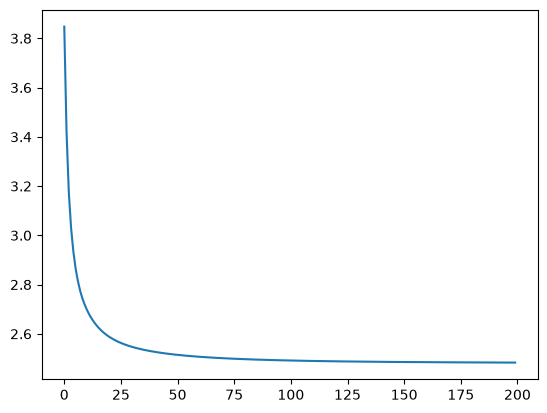

In [97]:
chars = sorted(list(set(''.join(words))))

stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

xs, ys = [],[]
for w in words: 
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs,chs[1:]):
        xi = stoi[ch1]
        yi = stoi[ch2]
        xs.append(xi)
        ys.append(yi)

#init
xs = torch.tensor(xs)
ys = torch.tensor(ys)
g = torch.Generator().manual_seed(1)
xenc = F.one_hot(xs,num_classes=27).float()
W = torch.randn((27,27), generator=g, requires_grad=True)
num = xs.nelement()

losslist = []

for k in range(200):
    #forward
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1,keepdims=True)
    #ix = torch.multinomial(probs, num_samples=1, replacement=True, generator = g)
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
    print(loss.item())
    losslist.append(loss.item())

    #backward
    W.grad = None
    loss.backward()

    #update
    W.data += -50 * W.grad
plt.plot(losslist)


In [94]:
g = torch.Generator().manual_seed(1)
for k in range(10):
    out = []
    ix =  0

    while True:
        xenc = F.one_hot(torch.tensor([ix]),num_classes=27).float()
        logits = xenc @ W
        counts = logits.exp()
        probs = counts / counts.sum(1, keepdims=True)

        ix = torch.multinomial(probs, num_samples=1,replacement = True, generator = g).item()
        if ix == 0:
            break
        out.append(itos[ix])
    print(''.join(out))

anzorig
lia
ay
h
jxaliss
mele
bemartri
rielciylendumadepionyonera
d
celilonalalieysh


Using device: mps
